SIMA.BHZ.KO


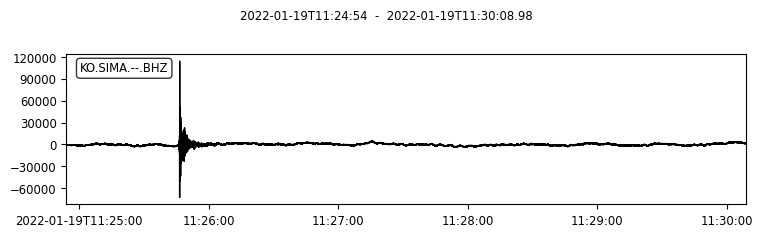

KULA.BHZ.KO


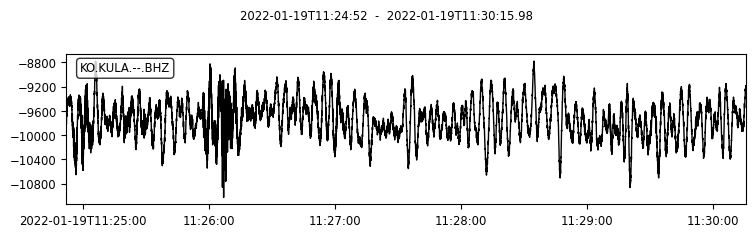

GEDZ.BHZ.KO


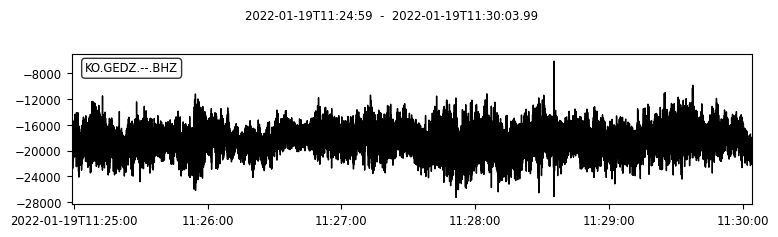

TVSB.BHZ.KO


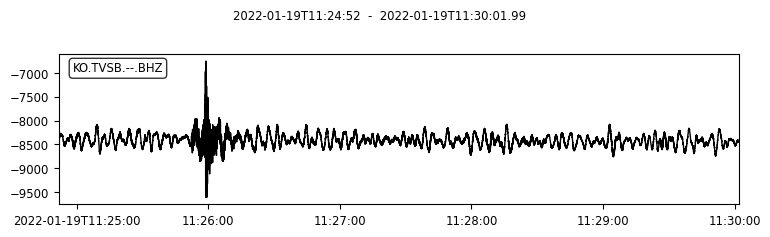

In [17]:
import os
from obspy.core import read


dir_path = '.'
save_path = './text_data'

for file_name in os.listdir(dir_path):

    if os.path.isfile(os.path.join(dir_path, file_name)) and os.path.join(dir_path, file_name).format().endswith("BHZ.KO"):
        print(file_name)
        
        track = read(os.path.join(dir_path, file_name))
        track.plot()

        with open(os.path.join(save_path, file_name.replace(".BHZ.KO", ".txt")), 'w') as f:
            for nth,data in enumerate(track[0].data):
                f.write(str(data))
                if(nth+1 != len(track[0].data)):
                    f.write(' ')



In [ ]:
# Import the clean_sac_file function from the previous example
from obspy import read, Trace, Stream
from obspy.signal.filter import bandpass

def clean_sac_file(input_file, output_file, freq_min, freq_max):
    """
    Applies a bandpass filter to a SAC file to clean noise.

    Inputs:
    - input_file: path to the input SAC file
    - output_file: path to the output SAC file
    - freq_min: minimum frequency of the passband in Hz
    - freq_max: maximum frequency of the passband in Hz
    """
    # Read in the SAC file as an ObsPy Trace object
    trace = read(input_file)[0]

    # Apply a bandpass filter to the trace
    trace_filtered = trace.copy()
    trace_filtered.data = bandpass(trace.data, freqmin=freq_min, freqmax=freq_max, df=trace.stats.sampling_rate)

    # Write the filtered trace to a new SAC file
    trace_filtered.write(output_file, format='SAC')

# Test the clean_sac_file function on an example SAC file
input_file = "./GEDZ.BHZ.KO"
output_file = "example_filtered2.sac"
freq_min = 1.0
freq_max = 10.0
clean_sac_file(input_file, output_file, freq_min, freq_max)

# Verify that the filtered SAC file was created
trace_filtered = read(output_file)[0]
print(trace_filtered)


clean_sac_file = read("./example_filtered2.sac")
clean_sac_file.plot()